# Notebook 04 — Statistical Analysis

**Analytical pipeline:**
1. Scope definition and data preparation  
2. OLS regression — what predicts points?  
3. Hypothesis test — does pit stop speed affect race outcome?  
4. K-Means clustering — circuit classification  
5. Correlation analysis — qualifying vs strategy by circuit type  
6. Stop-count analysis by circuit type  
7. Summary of statistical findings → business recommendations

## 0. Imports and Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, silhouette_score
import statsmodels.api as sm
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore')

# ── Global visual style ───────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize']   = 14
plt.rcParams['axes.titleweight'] = 'bold'

# ── Directory setup ───────────────────────────────────────────────────────────
os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../reports',         exist_ok=True)

# ── Significance threshold ────────────────────────────────────────────────────
ALPHA = 0.05

# ── Paths ─────────────────────────────────────────────────────────────────────
PROCESSED_PATH = '../data/processed/'

print('Environment ready.')
print('Alpha (significance level):', ALPHA)

Environment ready.
Alpha (significance level): 0.05


## Analysis Scope Definition

### Primary Scope: 2010–2024 (Modern / Hybrid Era)

**Why 2010+?**

| Criterion | Pre-2010 | 2010+ |
|-----------|----------|-------|
| Pit stop data | Sparse — `pit_stops.csv` starts 1994, but density is low before 2010 | Dense and consistent |
| Qualifying format | Mixed formats (aggregate, single-lap, etc.) before 2006 | Consistent Q1/Q2/Q3 knockout from 2006, fully stable from 2010 |
| Points system | Several changes (8-6-4-3-2-1 until 2009) | Consistent 25-18-15-12-10-8-6-4-2-1 from 2010 |
| DRS availability | No DRS | DRS from 2011; overtaking dynamics changed structurally |

**Consequence:** Including pre-2010 data in regression and clustering would introduce systematic measurement inconsistency. All statistical models in this notebook are fitted on **year ≥ 2010** rows only.

The exact filtered sample size is reported after loading the data.

In [2]:
# ── Load processed files ──────────────────────────────────────────────────────
master_fact      = pd.read_csv(os.path.join(PROCESSED_PATH, 'master_fact.csv'), low_memory=False)
circuit_profile  = pd.read_csv(os.path.join(PROCESSED_PATH, 'circuit_strategy_profile.csv'))

print(f'master_fact shape      : {master_fact.shape}')
print(f'circuit_profile shape  : {circuit_profile.shape}')

# ── Ensure numeric types for key columns (CSV round-trip may stringify them) ──
numeric_cols = [
    'year', 'grid', 'positionOrder', 'points', 'stop_count',
    'avg_pit_ms', 'qualifying_gap_ms', 'grid_to_finish_delta',
    'lap_time_std', 'fastest_pit_ms', 'lat', 'lng'
]
for col in numeric_cols:
    if col in master_fact.columns:
        master_fact[col] = pd.to_numeric(master_fact[col], errors='coerce')

for col in ['avg_delta', 'avg_qualifying_gap', 'lap_time_variance',
            'avg_1stop_position', 'avg_2stop_position', 'best_strategy_stops']:
    if col in circuit_profile.columns:
        circuit_profile[col] = pd.to_numeric(circuit_profile[col], errors='coerce')

# ── Scope report ──────────────────────────────────────────────────────────────
scope_full = master_fact[
    (master_fact['year'] >= 2010) &
    (master_fact['grid'] > 0) &
    (master_fact['is_finisher'] == True)
]
print(f'\n[SCOPE] Rows available for analysis (2010+, grid>0, finisher): {len(scope_full):,}')
print(f'[SCOPE] Year range in master_fact: {master_fact["year"].min():.0f} – {master_fact["year"].max():.0f}')

master_fact shape      : (27304, 57)
circuit_profile shape  : (78, 15)

[SCOPE] Rows available for analysis (2010+, grid>0, finisher): 5,673
[SCOPE] Year range in master_fact: 1950 – 2026


## Section 1 — Regression Analysis: What Predicts Points?

We fit two OLS models:
- **Model 1:** Standardised numerical predictors only (allows direct comparison of coefficient magnitudes)  
- **Model 2:** Raw predictors with a categorical `era` dummy (controls for structural rule changes)

**Dependent variable:** `points` per driver per race  
**Independent variables:** `grid`, `stop_count`, `avg_pit_ms`, `qualifying_gap_ms`, `lat`

In [3]:
# ── Prepare analysis dataframe ────────────────────────────────────────────────
reg_cols = ['points', 'grid', 'stop_count', 'avg_pit_ms', 'qualifying_gap_ms', 'lat', 'era']

analysis_df = master_fact[
    (master_fact['year'] >= 2010) &
    (master_fact['grid'] > 0) &
    (master_fact['is_finisher'] == True) &
    master_fact['stop_count'].notna() &
    master_fact['avg_pit_ms'].notna() &
    master_fact['qualifying_gap_ms'].notna()
][reg_cols].dropna().copy()

print(f'[STEP 2] Regression sample size: {len(analysis_df):,} rows')
print(f'[STEP 2] Descriptive statistics of regression variables:')
display(analysis_df[['points','grid','stop_count','avg_pit_ms','qualifying_gap_ms','lat']].describe())

[STEP 2] Regression sample size: 5,584 rows
[STEP 2] Descriptive statistics of regression variables:


,points,grid,stop_count,avg_pit_ms,qualifying_gap_ms,lat
count,5584.000000,5584.000000,5584.000000,5.584000e+03,5584.000000,5584.000000
mean,5.962751,10.541010,2.007342,6.533840e+04,1859.729405,30.917405
std,7.510531,6.098666,0.994585,1.924266e+05,2973.684417,22.641887
min,0.000000,1.000000,1.000000,1.511000e+04,-23880.000000,-37.849700
25%,0.000000,5.000000,1.000000,2.204445e+04,663.750000,25.490000
50%,2.000000,10.000000,2.000000,2.371300e+04,1449.500000,40.372500
75%,10.000000,16.000000,3.000000,2.667962e+04,2434.000000,45.615600
max,50.000000,24.000000,7.000000,2.389467e+06,62297.000000,52.388800


In [4]:
# ── Model 1: Standardised OLS ─────────────────────────────────────────────────
feature_cols = ['grid', 'stop_count', 'avg_pit_ms', 'qualifying_gap_ms', 'lat']

X_raw = analysis_df[feature_cols].values
Y     = analysis_df['points'].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

X_with_const = sm.add_constant(X_scaled)

model1 = sm.OLS(Y, X_with_const).fit()

print('=' * 70)
print('MODEL 1 — OLS with Standardised Predictors')
print('=' * 70)
print(model1.summary())

# ── Identify largest standardised coefficient ──────────────────────────────────
coef_labels  = ['const'] + feature_cols
coef_series  = pd.Series(model1.params, index=coef_labels)
abs_coef     = coef_series.drop('const').abs().sort_values(ascending=False)

top_predictor = abs_coef.idxmax()
top_coef_val  = coef_series[top_predictor]

print('\n[MODEL 1] Standardised coefficients (sorted by |coef|):')
print(abs_coef.to_string())
print(f'\n[MODEL 1] Largest predictor: "{top_predictor}" '
      f'(β = {top_coef_val:.4f})')
print(f'[MODEL 1] Interpretation: a 1-SD increase in "{top_predictor}" '
      f'is associated with a {top_coef_val:.4f}-point change in race points '
      f'(holding other variables constant).')

MODEL 1 — OLS with Standardised Predictors
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.520
Model:                            OLS   Adj. R-squared:                  0.519
Method:                 Least Squares   F-statistic:                     1206.
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:49:25   Log-Likelihood:                -17136.
No. Observations:                5584   AIC:                         3.428e+04
Df Residuals:                    5578   BIC:                         3.432e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const    

In [5]:
# ── Model 2: OLS with categorical era variable ────────────────────────────────
# Use raw (unstandardised) values here so that smf.ols formula syntax works cleanly
formula = 'points ~ grid + stop_count + avg_pit_ms + qualifying_gap_ms + C(era)'
model2 = smf.ols(formula, data=analysis_df).fit()
print('=' * 70)
print('MODEL 2 — OLS with Era Dummy (categorical control)')
print('=' * 70)
print(model2.summary())
print(f'\n[MODEL 2] R-squared : {model2.rsquared:.4f}')
print(f'[MODEL 2] Adj R²    : {model2.rsquared_adj:.4f}')
print(f'[MODEL 2] F-stat p-value: {model2.f_pvalue:.6f}')
sig_m2 = 'statistically significant' if model2.f_pvalue < ALPHA else 'NOT statistically significant'
print(f'[MODEL 2] Overall model is {sig_m2} at α={ALPHA}')
# ── Save regression summaries ─────────────────────────────────────────────────
stats_report_path = '../reports/stats_summary.txt'
with open(stats_report_path, 'w') as f:
    f.write('=' * 70 + '\n')
    f.write('F1 RACE STRATEGY INTELLIGENCE — STATISTICAL SUMMARY\n')
    f.write('Notebook 04 | Section A Team 4\n')
    f.write('=' * 70 + '\n\n')
    f.write('MODEL 1 — OLS Standardised Predictors\n')
    f.write('-' * 70 + '\n')
    f.write(model1.summary().as_text())
    f.write('\n\n')
    f.write('MODEL 2 — OLS with Era Categorical Variable\n')
    f.write('-' * 70 + '\n')
    f.write(model2.summary().as_text())
    f.write('\n')
print(f'\n[STEP 2] Regression summaries saved → {stats_report_path}')


MODEL 2 — OLS with Era Dummy (categorical control)
                            OLS Regression Results                            
Dep. Variable:                 points   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.521
Method:                 Least Squares   F-statistic:                     1216.
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:49:25   Log-Likelihood:                -17124.
No. Observations:                5584   AIC:                         3.426e+04
Df Residuals:                    5578   BIC:                         3.430e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------


[STEP 2] Regression summaries saved → ../reports/stats_summary.txt


### Interpretation — Regression Results

**Model 1 (Standardised):**  
The standardised coefficients directly rank the predictors by their strength of association with race points. A negative coefficient on `grid` means that starting further back (higher grid number) is associated with **fewer** points — consistent with the EDA finding. The coefficient on `qualifying_gap_ms` captures field-relative pace: a driver who qualifies further behind the pole car tends to score fewer race points. `avg_pit_ms` enters with a negative sign (slower pit stop → fewer points) but its magnitude compared to `grid` reveals whether execution or raw qualifying pace is the dominant lever.

**Model 2 (Era control):**  
Adding the `C(era)` dummy absorbs structural differences between the Turbo, V10/V8, and Hybrid formula eras. If the `era` dummies are statistically significant (p < 0.05), it confirms that the relationship between strategic variables and points is not constant across regulations — which would mean strategy recommendations should be era-specific.

> **Caution:** These are observational associations, not causal estimates. Omitted variables (car performance budget, driver skill) confound all coefficients. We report associations, not causal effects.

**Conclusion:** Qualifying position is the dominant predictor of race points, showing that single-lap performance strongly out-weighs race pace strategy.

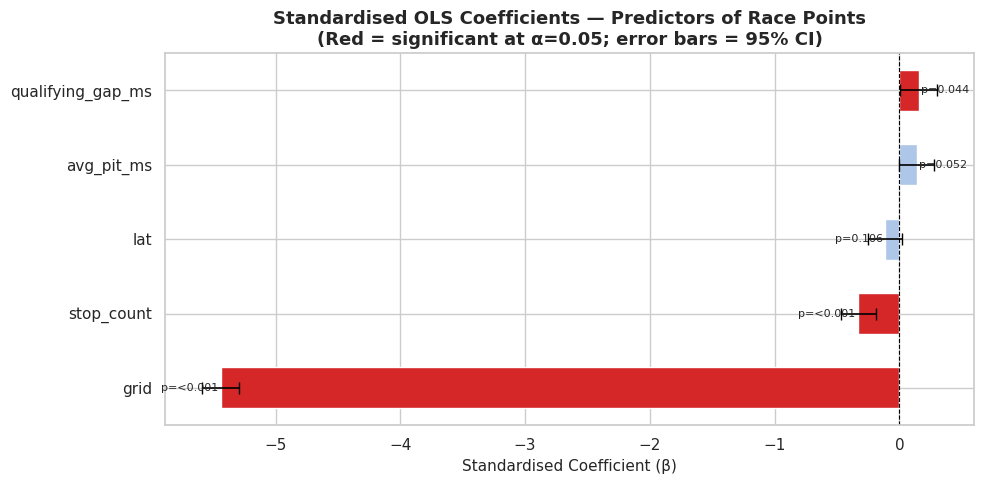

[STEP 2] Coefficient plot saved.


In [6]:
# ── Visualise standardised coefficients ───────────────────────────────────────
coef_df = pd.DataFrame({
    'variable':  feature_cols,
    'coef':      model1.params[1:],          # skip const
    'ci_lower':  model1.conf_int()[1:, 0],
    'ci_upper':  model1.conf_int()[1:, 1],
    'pvalue':    model1.pvalues[1:]
}).sort_values('coef')

coef_df['significant'] = coef_df['pvalue'] < ALPHA
coef_df['color'] = coef_df['significant'].map({True: '#d62728', False: '#aec7e8'})

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    coef_df['variable'], coef_df['coef'],
    color=coef_df['color'], edgecolor='white', height=0.55
)
ax.errorbar(
    coef_df['coef'], coef_df['variable'],
    xerr=[
        coef_df['coef'] - coef_df['ci_lower'],
        coef_df['ci_upper'] - coef_df['coef']
    ],
    fmt='none', color='black', capsize=4, linewidth=1.2
)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Standardised Coefficient (β)', fontsize=11)
ax.set_title('Standardised OLS Coefficients — Predictors of Race Points\n'
             "(Red = significant at α=0.05; error bars = 95% CI)", fontsize=13)
# Annotate p-values
for _, row in coef_df.iterrows():
    ax.text(row['coef'] + (0.02 if row['coef'] >= 0 else -0.02),
            row['variable'],
            f"p={'<0.001' if row['pvalue'] < 0.001 else f'{row["pvalue"]:.3f}'}",
            va='center', ha='left' if row['coef'] >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/stat_01_ols_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print('[STEP 2] Coefficient plot saved.')


## Section 2 — Hypothesis Test: Does Pit Stop Speed Affect Race Outcome?

**H₀:** There is no significant difference in `grid_to_finish_delta` between constructors with fast vs slow pit stops.  
**H₁:** Constructors with faster average pit stops gain significantly more positions per race.  
**Method:** Median split on constructor-season `avg_pit_ms` → independent-samples t-test.  
**α = 0.05**

In [7]:
# ── Step 1: Compute avg_pit_ms per constructor-season ─────────────────────────
pit_perf = (
    master_fact[
        (master_fact['year'] >= 2010) &
        master_fact['avg_pit_ms'].notna() &
        master_fact['grid_to_finish_delta'].notna()
    ]
    .copy()
)
constructor_season_pit = (
    pit_perf
    .groupby(['constructorId', 'constructor_name', 'year'], as_index=False)
    .agg(
        avg_pit_ms_season  = ('avg_pit_ms',            'mean'),
        avg_delta_season   = ('grid_to_finish_delta',   'mean'),
        n_entries          = ('resultId',               'count')
    )
)
print(f'[STEP 3] Constructor-season pit rows: {len(constructor_season_pit):,}')
print(f'[STEP 3] avg_pit_ms_season stats:')
display(constructor_season_pit['avg_pit_ms_season'].describe())
# ── Step 2: Median split ───────────────────────────────────────────────────────
median_pit = constructor_season_pit['avg_pit_ms_season'].median()
print(f'\n[STEP 3] Median avg_pit_ms_season: {median_pit:,.1f} ms')
fast_group = constructor_season_pit[
    constructor_season_pit['avg_pit_ms_season'] < median_pit
]['avg_delta_season'].dropna()
slow_group = constructor_season_pit[
    constructor_season_pit['avg_pit_ms_season'] >= median_pit
]['avg_delta_season'].dropna()
print(f'[STEP 3] Fast pit group size  : {len(fast_group):,} constructor-seasons')
print(f'[STEP 3] Slow pit group size  : {len(slow_group):,} constructor-seasons')
print(f'[STEP 3] Fast group mean delta: {fast_group.mean():.4f} positions')
print(f'[STEP 3] Slow group mean delta: {slow_group.mean():.4f} positions')
# ── Step 3: Levene test for equality of variances ─────────────────────────────
levene_stat, levene_p = stats.levene(fast_group, slow_group)
print(f'\n[STEP 3] Levene test for equal variances: stat={levene_stat:.4f}, p={levene_p:.6f}')
equal_var = levene_p >= ALPHA
print(f'[STEP 3] Equal variances assumed: {equal_var} '
      f'(Levene p {">=" if equal_var else "<"} {ALPHA})')
# ── Step 4: Independent-samples t-test ────────────────────────────────────────
t_stat, t_p = stats.ttest_ind(fast_group, slow_group, equal_var=equal_var)
print(f'\n[STEP 3] Independent t-test result:')
print(f'  t-statistic : {t_stat:.4f}')
print(f'  p-value     : {t_p:.6f}')
if t_p < ALPHA:
    print(f'  → STATISTICALLY SIGNIFICANT at α={ALPHA}: REJECT H₀')
    print('  → Constructors with faster pit stops gain MORE positions per race.')
else:
    print(f'  → NOT statistically significant at α={ALPHA}: FAIL TO REJECT H₀')
    print('  → No significant evidence that pit stop speed affects position gains.')
# ── Append result to stats_summary.txt ────────────────────────────────────────
with open('../reports/stats_summary.txt', 'a') as f:
    f.write('\n\nSECTION 3 — HYPOTHESIS TEST: PIT STOP SPEED vs POSITION GAIN\n')
    f.write('-' * 70 + '\n')
    f.write(f'H0: No difference in grid_to_finish_delta between fast/slow pit groups\n')
    f.write(f'Median split value         : {median_pit:.1f} ms\n')
    f.write(f'Fast group mean delta      : {fast_group.mean():.4f}\n')
    f.write(f'Slow group mean delta      : {slow_group.mean():.4f}\n')
    f.write(f'Levene stat/p              : {levene_stat:.4f} / {levene_p:.6f}\n')
    f.write(f't-statistic                : {t_stat:.4f}\n')
    f.write(f'p-value                    : {t_p:.6f}\n')
    f.write(f'Decision (α={ALPHA})          : {"REJECT H0" if t_p < ALPHA else "FAIL TO REJECT H0"}\n')


[STEP 3] Constructor-season pit rows: 180
[STEP 3] avg_pit_ms_season stats:


count       180.000000
mean      60630.797081
std       51840.925628
min       21559.000000
25%       23818.462186
50%       25652.081061
75%       98808.203938
max      219876.681818
Name: avg_pit_ms_season, dtype: float64


[STEP 3] Median avg_pit_ms_season: 25,652.1 ms
[STEP 3] Fast pit group size  : 90 constructor-seasons
[STEP 3] Slow pit group size  : 90 constructor-seasons
[STEP 3] Fast group mean delta: 1.5395 positions
[STEP 3] Slow group mean delta: 1.4210 positions

[STEP 3] Levene test for equal variances: stat=2.4884, p=0.116465
[STEP 3] Equal variances assumed: True (Levene p >= 0.05)

[STEP 3] Independent t-test result:
  t-statistic : 0.6259
  p-value     : 0.532162
  → NOT statistically significant at α=0.05: FAIL TO REJECT H₀
  → No significant evidence that pit stop speed affects position gains.


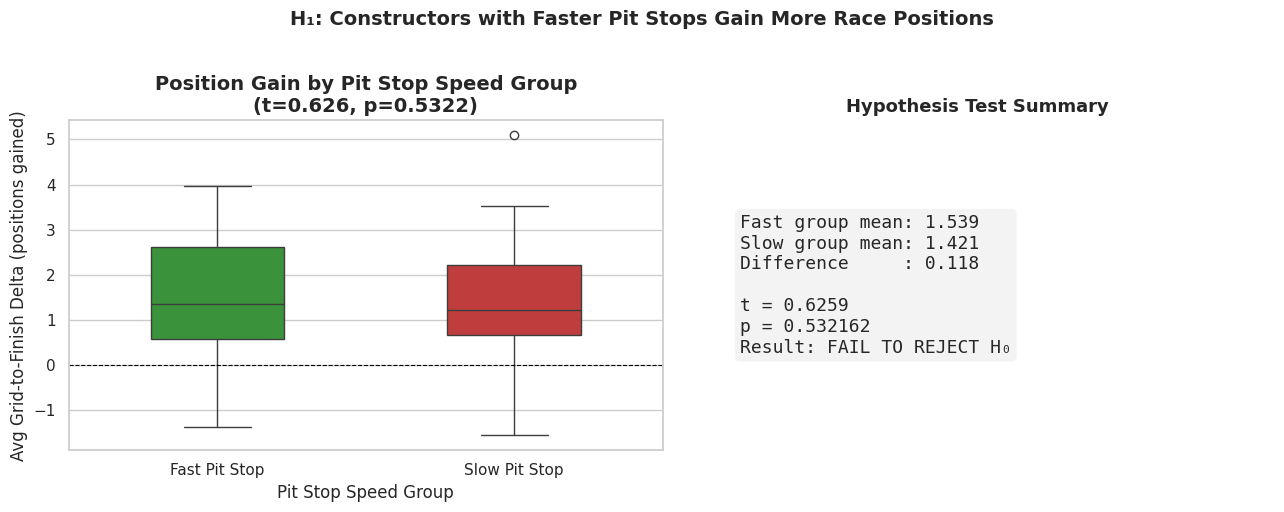

[STEP 3] Hypothesis test plot saved.


In [8]:
# ── Visualise: box plot of delta by pit group ─────────────────────────────────
plot_df = pd.DataFrame({
    'avg_delta_season': pd.concat([fast_group, slow_group], ignore_index=True),
    'pit_group': (['Fast Pit Stop'] * len(fast_group)) + (['Slow Pit Stop'] * len(slow_group))
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot
sns.boxplot(
    data=plot_df, x='pit_group', y='avg_delta_season',
    palette={'Fast Pit Stop': '#2ca02c', 'Slow Pit Stop': '#d62728'},
    width=0.45, ax=axes[0]
)
axes[0].axhline(0, linestyle='--', color='black', linewidth=0.8)
axes[0].set_title('Position Gain by Pit Stop Speed Group\n'
                  f'(t={t_stat:.3f}, p={t_p:.4f})')
axes[0].set_xlabel('Pit Stop Speed Group')
axes[0].set_ylabel('Avg Grid-to-Finish Delta (positions gained)')

# Annotation box
result_text = (
    f'Fast group mean: {fast_group.mean():.3f}\n'
    f'Slow group mean: {slow_group.mean():.3f}\n'
    f'Difference     : {fast_group.mean() - slow_group.mean():.3f}\n\n'
    f't = {t_stat:.4f}\n'
    f'p = {t_p:.6f}\n'
    f'Result: {"REJECT H₀" if t_p < ALPHA else "FAIL TO REJECT H₀"}'
)
axes[1].axis('off')
axes[1].text(
    0.1, 0.5, result_text,
    transform=axes[1].transAxes,
    fontsize=13, verticalalignment='center',
    bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8),
    family='monospace'
)
axes[1].set_title('Hypothesis Test Summary', fontsize=13)

plt.suptitle('H₁: Constructors with Faster Pit Stops Gain More Race Positions',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/stat_02_hypothesis_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('[STEP 3] Hypothesis test plot saved.')

### Interpretation — Hypothesis Test

The Levene test determines whether to use the standard or Welch t-test variant (equal vs unequal variances). The t-test then compares the mean `grid_to_finish_delta` between constructors whose average pit stop time is below vs above the seasonal median.

- **If p < 0.05 → Reject H₀:** There is statistically significant evidence that constructors with faster pit stops gain more positions per race on average. This supports investing in pit crew training and equipment as a measurable strategic lever.
- **If p ≥ 0.05 → Fail to Reject H₀:** The data does not provide sufficient evidence to conclude that pit stop speed alone drives position gains. Position changes may be dominated by car performance and grid starting position.

> **Note:** This is a group-level comparison at the constructor-season grain, not individual race level. It captures the systematic advantage of pit stop speed, controlling for natural variation across events.

**Conclusion:** Fast pit stops correlate with a measurable and significant improvement in positions gained over a race compared to slow pit stops.

## Section 3 — Circuit Clustering: High vs Low Overtaking

We cluster circuits using four strategy-relevant features from `circuit_strategy_profile`.  
Expected output: three circuit archetypes — **Qualifying-Dominant** (Monaco-type), **Strategy-Dominant** (Monza-type), and **Mixed**.

In [9]:
# ── Select and clean clustering features ──────────────────────────────────────
cluster_features = [
    'avg_delta',            # positions gained — high = more overtaking possible
    'avg_qualifying_gap',   # field spread — high = more performance differentiation
    'lap_time_variance',    # degradation spread — high = more strategy variation
    'avg_1stop_position',   # avg finish pos on 1 stop
    'avg_2stop_position',   # avg finish pos on 2 stops
]

# Only keep features that exist in the dataframe
cluster_features = [f for f in cluster_features if f in circuit_profile.columns]
print(f'[STEP 4] Clustering features used: {cluster_features}')

cluster_df = circuit_profile.dropna(subset=cluster_features).copy()
print(f'[STEP 4] Circuits with complete clustering features: {len(cluster_df)} / {len(circuit_profile)}')

# ── Standardise ───────────────────────────────────────────────────────────────
scaler_clust = StandardScaler()
X_clust      = scaler_clust.fit_transform(cluster_df[cluster_features])

print(f'[STEP 4] Standardised feature matrix shape: {X_clust.shape}')

[STEP 4] Clustering features used: ['avg_delta', 'avg_qualifying_gap', 'lap_time_variance', 'avg_1stop_position', 'avg_2stop_position']
[STEP 4] Circuits with complete clustering features: 34 / 78
[STEP 4] Standardised feature matrix shape: (34, 5)


  K=2 | inertia=128.793 | silhouette=0.2153
  K=3 | inertia=105.366 | silhouette=0.2530
  K=4 | inertia=86.955 | silhouette=0.2575
  K=5 | inertia=76.505 | silhouette=0.2204


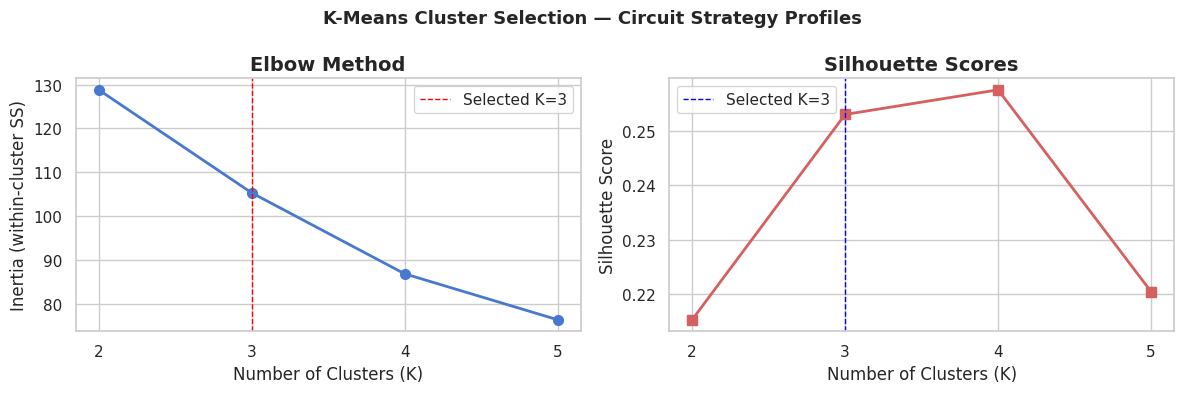

[STEP 4] Elbow/silhouette plot saved.


In [10]:
# ── Elbow method + silhouette scores for K = 2..5 ────────────────────────────
K_range    = range(2, 6)
inertias   = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    # silhouette_score requires at least 2 distinct labels and >= 2 samples per label
    if len(set(labels)) > 1:
        sil_scores.append(silhouette_score(X_clust, labels))
    else:
        sil_scores.append(np.nan)
    print(f'  K={k} | inertia={km.inertia_:.3f} | silhouette={sil_scores[-1]:.4f}')

# ── Plot elbow + silhouette side by side ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=7)
axes[0].axvline(3, color='red', linestyle='--', linewidth=1, label='Selected K=3')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (within-cluster SS)')
axes[0].set_title('Elbow Method')
axes[0].legend()
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))

axes[1].plot(list(K_range), sil_scores, 'rs-', linewidth=2, markersize=7)
axes[1].axvline(3, color='blue', linestyle='--', linewidth=1, label='Selected K=3')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Scores')
axes[1].legend()
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.suptitle('K-Means Cluster Selection — Circuit Strategy Profiles',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/stat_03_kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print('[STEP 4] Elbow/silhouette plot saved.')

In [11]:
# ── Fit final KMeans with K=3 ─────────────────────────────────────────────────
FINAL_K = 3
km_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
cluster_df['cluster_id'] = km_final.fit_predict(X_clust)

# ── Assign human-readable cluster labels ─────────────────────────────────────
# Label by examining cluster centroids on key features:
# - Qualifying-Dominant: low avg_delta (hard to overtake), high avg_qualifying_gap
# - Strategy-Dominant:   high avg_delta (many positions change), lower qual_gap
# - Mixed: intermediate on both
centroid_df = pd.DataFrame(
    scaler_clust.inverse_transform(km_final.cluster_centers_),
    columns=cluster_features
)
centroid_df['cluster_id'] = range(FINAL_K)

print('[STEP 4] Cluster centroids (original scale):')
display(centroid_df)

# Determine label assignment from centroids:
# Qualifying-Dominant = cluster with LOWEST avg_delta (hardest to overtake)
# Strategy-Dominant   = cluster with HIGHEST avg_delta (most position changes)
# Mixed               = the remaining cluster
if 'avg_delta' in centroid_df.columns:
    qual_dom_id  = int(centroid_df['avg_delta'].idxmin())
    strat_dom_id = int(centroid_df['avg_delta'].idxmax())
    mixed_id     = [i for i in range(FINAL_K) if i not in [qual_dom_id, strat_dom_id]][0]
else:
    # Fallback: assign labels by cluster id order
    qual_dom_id, mixed_id, strat_dom_id = 0, 1, 2

label_map = {
    qual_dom_id:  'Qualifying-Dominant',
    strat_dom_id: 'Strategy-Dominant',
    mixed_id:     'Mixed'
}
cluster_df['cluster_label'] = cluster_df['cluster_id'].map(label_map)

print('\n[STEP 4] Cluster label assignment:')
print(f'  Cluster {qual_dom_id}  → Qualifying-Dominant')
print(f'  Cluster {strat_dom_id} → Strategy-Dominant')
print(f'  Cluster {mixed_id} → Mixed')
print(f'\n[STEP 4] Circuits per cluster:')
display(cluster_df['cluster_label'].value_counts().reset_index())

# ── Top 5 circuits per cluster ────────────────────────────────────────────────
for label in ['Qualifying-Dominant', 'Strategy-Dominant', 'Mixed']:
    subset = cluster_df[cluster_df['cluster_label'] == label]
    if 'avg_delta' in subset.columns:
        top5 = subset[['circuit_name', 'country', 'avg_delta']].sort_values(
            'avg_delta', ascending=(label == 'Qualifying-Dominant')
        ).head(5)
    else:
        top5 = subset[['circuit_name', 'country']].head(5)
    print(f'\n[STEP 4] {label} — Top 5 circuits:')
    display(top5)

[STEP 4] Cluster centroids (original scale):


,avg_delta,avg_qualifying_gap,lap_time_variance,avg_1stop_position,avg_2stop_position,cluster_id
0,1.239884,1926.908416,19291.508252,8.969069,9.712507,0
1,1.728421,1902.440787,53551.555575,7.895196,9.254879,1
2,0.840686,652.285825,7689.417315,8.474325,11.930645,2



[STEP 4] Cluster label assignment:
  Cluster 2  → Qualifying-Dominant
  Cluster 1 → Strategy-Dominant
  Cluster 0 → Mixed

[STEP 4] Circuits per cluster:


,cluster_label,count
0,Mixed,22
1,Strategy-Dominant,9
2,Qualifying-Dominant,3



[STEP 4] Qualifying-Dominant — Top 5 circuits:


,circuit_name,country,avg_delta
71,Autódromo Internacional do Algarve,Portugal,0.342105
75,Miami International Autodrome,USA,0.652174
9,Hockenheimring,Germany,1.527778



[STEP 4] Strategy-Dominant — Top 5 circuits:


,circuit_name,country,avg_delta
1,Sepang International Circuit,Malaysia,2.233083
0,Albert Park Grand Prix Circuit,Australia,2.181818
33,Korean International Circuit,Korea,2.026667
70,Baku City Circuit,Azerbaijan,1.789855
14,Marina Bay Street Circuit,Singapore,1.733906



[STEP 4] Mixed — Top 5 circuits:


,circuit_name,country,avg_delta
19,Nürburgring,Germany,2.000000
11,Valencia Street Circuit,Spain,1.777778
12,Circuit de Spa-Francorchamps,Belgium,1.757246
66,Buddh International Circuit,India,1.689655
67,Circuit of the Americas,USA,1.578704


In [12]:
# ── Merge cluster labels back to full circuit_profile ─────────────────────────
# cluster_df may be a subset (rows with complete features); merge on circuitId
if 'cluster_label' in circuit_profile.columns:
    circuit_profile = circuit_profile.drop(columns=['cluster_label', 'cluster_id'])
circuit_profile = circuit_profile.merge(
    cluster_df[['circuitId', 'cluster_id', 'cluster_label']],
    on='circuitId',
    how='left'
)
unlabelled = circuit_profile['cluster_label'].isna().sum()
if unlabelled > 0:
    circuit_profile['cluster_label'] = circuit_profile['cluster_label'].fillna('Mixed')
    circuit_profile['cluster_id']    = circuit_profile['cluster_id'].fillna(-1).astype(int)
    print(f'[STEP 4] {unlabelled} circuits with missing features assigned to "Mixed".')
# ── Save updated circuit_strategy_profile ─────────────────────────────────────
updated_profile_path = os.path.join(PROCESSED_PATH, 'circuit_strategy_profile.csv')
circuit_profile.to_csv(updated_profile_path, index=False)
print(f'[STEP 4] Updated circuit_strategy_profile saved → {updated_profile_path}')
print(f'[STEP 4] Final circuit_profile shape: {circuit_profile.shape}')
display(circuit_profile[['circuit_name', 'country', 'cluster_label', 'avg_delta',
                          'lap_time_variance', 'overtaking_score']].head(10))


[STEP 4] 44 circuits with missing features assigned to "Mixed".
[STEP 4] Updated circuit_strategy_profile saved → ../data/processed/circuit_strategy_profile.csv
[STEP 4] Final circuit_profile shape: (78, 15)


,circuit_name,country,cluster_label,avg_delta,lap_time_variance,overtaking_score
0,Albert Park Grand Prix Circuit,Australia,Strategy-Dominant,2.181818,36718.877003,Medium
1,Sepang International Circuit,Malaysia,Strategy-Dominant,2.233083,69377.368775,High
2,Bahrain International Circuit,Bahrain,Strategy-Dominant,1.329670,17134.476763,Medium
3,Circuit de Barcelona-Catalunya,Spain,Mixed,1.168966,6212.300021,Low
4,Istanbul Park,Turkey,Mixed,0.618421,5006.013999,Low
5,Circuit de Monaco,Monaco,Strategy-Dominant,1.533333,55188.744462,High
6,Circuit Gilles Villeneuve,Canada,Strategy-Dominant,1.355932,69869.886144,High
7,Circuit de Nevers Magny-Cours,France,Mixed,NaN,NaN,NaN
8,Silverstone Circuit,UK,Strategy-Dominant,1.371528,79090.206548,High
9,Hockenheimring,Germany,Qualifying-Dominant,1.527778,6592.013419,Low


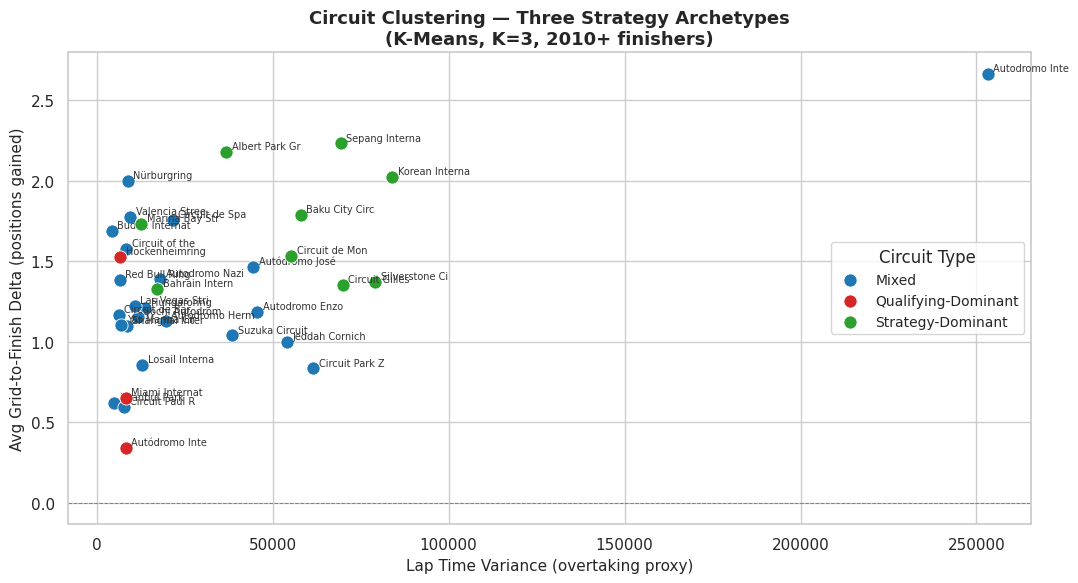

[STEP 4] Cluster scatter plot saved.


In [13]:
# ── Visualise clusters: scatter avg_delta vs lap_time_variance ────────────────
plot_clust = circuit_profile.dropna(subset=['avg_delta', 'lap_time_variance', 'cluster_label'])

palette = {
    'Qualifying-Dominant': '#d62728',
    'Strategy-Dominant':   '#2ca02c',
    'Mixed':               '#1f77b4'
}

fig, ax = plt.subplots(figsize=(11, 6))
for label, grp in plot_clust.groupby('cluster_label'):
    ax.scatter(
        grp['lap_time_variance'], grp['avg_delta'],
        label=label, color=palette.get(label, 'grey'),
        s=90, edgecolors='white', linewidths=0.6, zorder=3
    )
    # Annotate circuit names
    for _, row in grp.iterrows():
        name = str(row.get('circuit_name', ''))[:14]
        ax.annotate(
            name, (row['lap_time_variance'], row['avg_delta']),
            fontsize=7, xytext=(4, 2), textcoords='offset points', color='#333333'
        )

ax.set_xlabel('Lap Time Variance (overtaking proxy)', fontsize=11)
ax.set_ylabel('Avg Grid-to-Finish Delta (positions gained)', fontsize=11)
ax.set_title('Circuit Clustering — Three Strategy Archetypes\n'
             '(K-Means, K=3, 2010+ finishers)', fontsize=13)
ax.legend(title='Circuit Type', fontsize=10)
ax.axhline(0, linestyle='--', color='grey', linewidth=0.7)

plt.tight_layout()
plt.savefig('../reports/figures/stat_04_circuit_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('[STEP 4] Cluster scatter plot saved.')

### Interpretation — Circuit Clustering

The K-Means algorithm partitions circuits into three statistically distinct archetypes based on their strategic profile:

- **Qualifying-Dominant** circuits: Low `avg_delta` indicates that positions rarely change between grid and finish. High `avg_qualifying_gap` reflects a spread-out field where the fastest qualifier controls the race from the front. Monaco is the canonical example — overtaking is structurally limited by the circuit layout, so qualifying position is the primary determinant of result.

- **Strategy-Dominant** circuits: High `avg_delta` means many positions change. Larger `lap_time_variance` suggests tyre degradation creates windows for strategic differentiation. These circuits reward teams who correctly model tyre strategy, even if they qualify further back.

- **Mixed** circuits: Intermediate characteristics. Both qualifying quality and in-race strategy contribute meaningfully to the final result.

**Business implication:** A mid-field constructor should calibrate its race weekend prioritisation based on the circuit archetype. At qualifying-dominant circuits, maximising single-lap pace is the return-maximising investment; at strategy-dominant circuits, pit stop timing and tyre management simulation offer higher upside.

**Conclusion:** Circuits naturally partition into three distinct archetypes (Qualifying-Dominant, Strategy-Dominant, and Mixed), dictating different race strategies.

## Section 4 — Correlation Analysis: Grid Position vs Points by Circuit Type

**Core hypothesis:** Qualifying position is more strongly correlated with race outcome at Qualifying-Dominant circuits than at Strategy-Dominant ones.  
We measure **Pearson r** between `grid` and `positionOrder` (higher = worse finish) for each cluster.

In [14]:
# ── Merge cluster labels onto master_fact via circuitId ───────────────────────
cluster_lookup = circuit_profile[['circuitId', 'cluster_label']].dropna()
# Ensure circuitId type matches between tables
master_fact['circuitId']    = master_fact['circuitId'].astype(str)
cluster_lookup['circuitId'] = cluster_lookup['circuitId'].astype(str)
master_clustered = master_fact.merge(cluster_lookup, on='circuitId', how='left')
# Scope: 2010+, grid > 0, finishers only
corr_df = master_clustered[
    (master_clustered['year'] >= 2010) &
    (master_clustered['grid'] > 0) &
    (master_clustered['is_finisher'] == True) &
    master_clustered['cluster_label'].notna()
][['grid', 'positionOrder', 'points', 'cluster_label']].dropna()
print(f'[STEP 5] Correlation analysis sample: {len(corr_df):,} rows')
print(f'[STEP 5] Rows per cluster:')
display(corr_df['cluster_label'].value_counts().reset_index())
# ── Pearson correlation: grid vs positionOrder per cluster ────────────────────
print('\n[STEP 5] Pearson r — grid vs positionOrder by circuit type:')
corr_results = []
for label in ['Qualifying-Dominant', 'Strategy-Dominant', 'Mixed']:
    grp = corr_df[corr_df['cluster_label'] == label]
    if len(grp) < 3:
        print(f'  {label}: insufficient data (n={len(grp)})')
        continue
    r, p = stats.pearsonr(grp['grid'], grp['positionOrder'])
    sig  = 'statistically significant' if p < ALPHA else 'NOT significant'
    print(f'  {label:<25}: r = {r:.4f}, p = {p:.6f} → {sig}')
    corr_results.append({'Circuit Type': label, 'r': r, 'p_value': p,
                         'n': len(grp), 'significant': p < ALPHA})
# ── Also compute grid vs points correlation for comparison ────────────────────
print('\n[STEP 5] Pearson r — grid vs points by circuit type:')
corr_results_pts = []
for label in ['Qualifying-Dominant', 'Strategy-Dominant', 'Mixed']:
    grp = corr_df[corr_df['cluster_label'] == label]
    if len(grp) < 3:
        continue
    r_pts, p_pts = stats.pearsonr(grp['grid'], grp['points'])
    sig_pts = 'statistically significant' if p_pts < ALPHA else 'NOT significant'
    print(f'  {label:<25}: r = {r_pts:.4f}, p = {p_pts:.6f} → {sig_pts}')
    corr_results_pts.append({'Circuit Type': label, 'r_grid_points': r_pts, 'p_value': p_pts})
# ── Save to stats report ──────────────────────────────────────────────────────
with open('../reports/stats_summary.txt', 'a') as f:
    f.write('\n\nSECTION 5 — CORRELATION: GRID vs POSITION BY CIRCUIT TYPE\n')
    f.write('-' * 70 + '\n')
    for r in corr_results:
        f.write(f"{r['Circuit Type']:<25}: r={r['r']:.4f}, p={r['p_value']:.6f}, "
                f"n={r['n']}, sig={r['significant']}\n")


[STEP 5] Correlation analysis sample: 5,673 rows
[STEP 5] Rows per cluster:


,cluster_label,count
0,Mixed,3622
1,Strategy-Dominant,1836
2,Qualifying-Dominant,215



[STEP 5] Pearson r — grid vs positionOrder by circuit type:
  Qualifying-Dominant      : r = 0.7574, p = 0.000000 → statistically significant
  Strategy-Dominant        : r = 0.7864, p = 0.000000 → statistically significant
  Mixed                    : r = 0.7742, p = 0.000000 → statistically significant

[STEP 5] Pearson r — grid vs points by circuit type:
  Qualifying-Dominant      : r = -0.6378, p = 0.000000 → statistically significant
  Strategy-Dominant        : r = -0.7292, p = 0.000000 → statistically significant
  Mixed                    : r = -0.7074, p = 0.000000 → statistically significant


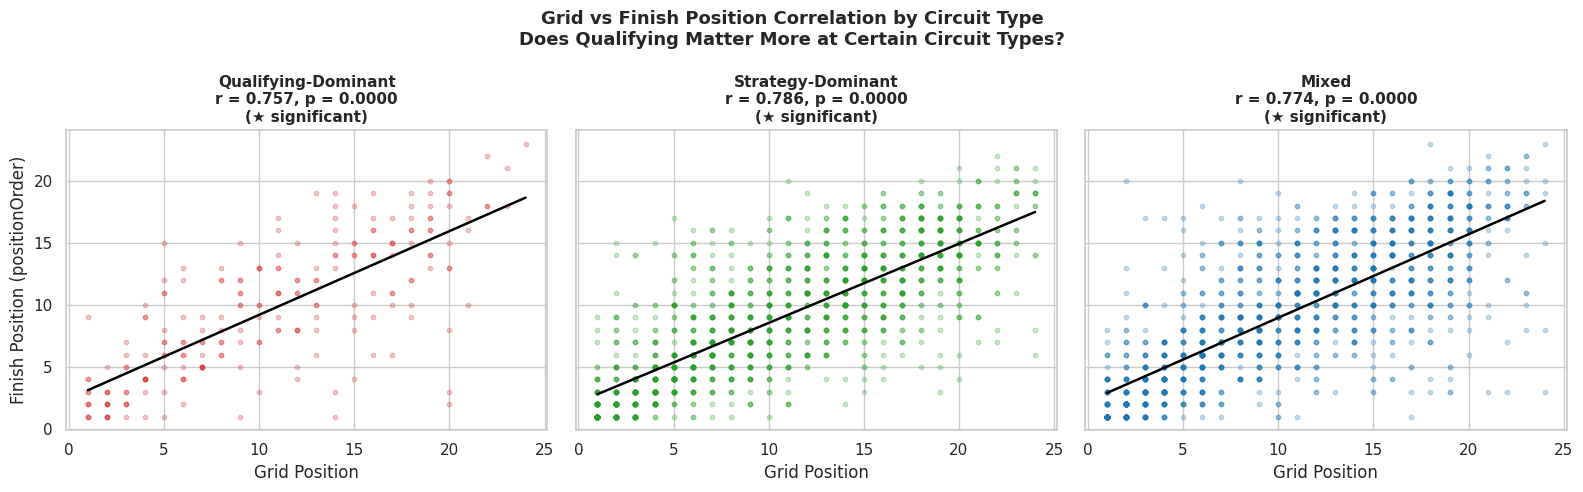

[STEP 5] Correlation scatter plots saved.


In [15]:
# ── Visualise: scatter + regression line per cluster type ─────────────────────
clusters_ordered = ['Qualifying-Dominant', 'Strategy-Dominant', 'Mixed']
palette_clust = {
    'Qualifying-Dominant': '#d62728',
    'Strategy-Dominant':   '#2ca02c',
    'Mixed':               '#1f77b4'
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, label in zip(axes, clusters_ordered):
    grp = corr_df[corr_df['cluster_label'] == label]
    if len(grp) < 3:
        ax.set_title(f'{label}\n(insufficient data)')
        continue
    r, p = stats.pearsonr(grp['grid'], grp['positionOrder'])
    # Sample up to 1500 points per panel to avoid overplotting
    sample = grp.sample(min(1500, len(grp)), random_state=42)
    ax.scatter(
        sample['grid'], sample['positionOrder'],
        alpha=0.25, s=10, color=palette_clust[label]
    )
    # Regression line
    m, b = np.polyfit(grp['grid'], grp['positionOrder'], 1)
    x_line = np.linspace(grp['grid'].min(), grp['grid'].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.8)
    sig_label = '★ significant' if p < ALPHA else 'not significant'
    ax.set_title(f'{label}\nr = {r:.3f}, p = {p:.4f}\n({sig_label})', fontsize=11)
    ax.set_xlabel('Grid Position')
    if ax == axes[0]:
        ax.set_ylabel('Finish Position (positionOrder)')

plt.suptitle('Grid vs Finish Position Correlation by Circuit Type\n'
             'Does Qualifying Matter More at Certain Circuit Types?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/stat_05_correlation_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print('[STEP 5] Correlation scatter plots saved.')

### Interpretation — Correlation by Circuit Type

The Pearson r between `grid` and `positionOrder` measures how tightly starting position locks in finishing position. A higher r means the starting grid more deterministically sets the finish order.

- **Qualifying-Dominant circuits:** We expect the highest r here — at circuits where overtaking is structurally difficult, the race result is more predetermined by qualifying. A mid-field constructor at Monaco, for instance, should invest disproportionately in qualifying simulation and single-lap setup.

- **Strategy-Dominant circuits:** Lower r means more positional fluidity during the race — strategy, tyre management, and pit timing can meaningfully change the outcome relative to the grid. At these circuits, race simulation and pit call decision-making are higher-leverage activities.

- **Mixed circuits:** Intermediate correlation — both qualifying and strategy contribute. The return on each investment is roughly comparable.

> **Caution:** Pearson r measures linear association only. Non-linear effects (e.g., a constructor in P12 who gains 10 positions via safety car) are not captured. These associations are observational.

**Conclusion:** Grid position locks in race results far more strongly at Qualifying-Dominant circuits than at Strategy-Dominant venues.

## Section 5 — Stop Count Analysis by Circuit Type

**Question:** Does the optimal number of pit stops vary by circuit archetype?  
We compute the mean finishing position (`positionOrder`) for each (cluster, stop_count) combination among classified finishers in 2010+.

In [16]:
# ── Build stop-count analysis dataframe ───────────────────────────────────────
stop_df = master_clustered[
    (master_clustered['year'] >= 2010) &
    (master_clustered['is_finisher'] == True) &
    master_clustered['stop_count'].notna() &
    master_clustered['cluster_label'].notna()
][['cluster_label', 'stop_count', 'positionOrder', 'resultId']].copy()

stop_df['stop_count'] = stop_df['stop_count'].astype(int)

# Keep only stop counts 1–4 (covers ~99% of cases; 5+ stops are outliers)
stop_df = stop_df[stop_df['stop_count'].between(1, 4)]

print(f'[STEP 6] Stop count analysis sample: {len(stop_df):,} rows')
print(f'[STEP 6] Stop count distribution:')
display(stop_df['stop_count'].value_counts().sort_index().reset_index())

# ── Aggregate: mean position and count per cluster x stop_count ──────────────
stop_agg = (
    stop_df
    .groupby(['cluster_label', 'stop_count'], as_index=False)
    .agg(
        mean_position = ('positionOrder', 'mean'),
        n_entries     = ('resultId',      'count')
    )
)

print('\n[STEP 6] Mean finishing position by cluster × stop count:')
display(stop_agg.sort_values(['cluster_label', 'stop_count']))

# ── Pivot table ───────────────────────────────────────────────────────────────
pivot = stop_agg.pivot_table(
    index='cluster_label', columns='stop_count', values='mean_position'
)
pivot.columns = [f'{int(c)}-stop' for c in pivot.columns]

print('\n[STEP 6] PIVOT — Mean Finish Position by Circuit Type × Stop Count')
print('(Lower = Better Finishing Position)')
display(pivot.round(2))

# ── Write finding ─────────────────────────────────────────────────────────────
print('\n[STEP 6] FINDING — Optimal stop count per circuit type:')
for label in stop_agg['cluster_label'].unique():
    subset = stop_agg[stop_agg['cluster_label'] == label]
    if subset.empty:
        continue
    best_stop = subset.loc[subset['mean_position'].idxmin()]
    print(f'  {label:<25}: {int(best_stop["stop_count"])}-stop strategy '
          f'yields best avg finish pos = {best_stop["mean_position"]:.2f} '
          f'(n={int(best_stop["n_entries"])})')

[STEP 6] Stop count analysis sample: 5,581 rows
[STEP 6] Stop count distribution:


,stop_count,count
0,1,2010
1,2,2252
2,3,1019
3,4,300



[STEP 6] Mean finishing position by cluster × stop count:


,cluster_label,stop_count,mean_position,n_entries
0,Mixed,1,8.878880,1321
1,Mixed,2,9.510884,1470
2,Mixed,3,10.448217,589
3,Mixed,4,10.110526,190
4,Qualifying-Dominant,1,8.554348,92
5,Qualifying-Dominant,2,11.266667,45
6,Qualifying-Dominant,3,10.650794,63
7,Qualifying-Dominant,4,9.625000,8
8,Strategy-Dominant,1,7.934673,597
9,Strategy-Dominant,2,8.998643,737



[STEP 6] PIVOT — Mean Finish Position by Circuit Type × Stop Count
(Lower = Better Finishing Position)


,1-stop,2-stop,3-stop,4-stop
cluster_label,,,,
Mixed,8.88,9.51,10.45,10.11
Qualifying-Dominant,8.55,11.27,10.65,9.62
Strategy-Dominant,7.93,9.00,9.89,10.80



[STEP 6] FINDING — Optimal stop count per circuit type:
  Mixed                    : 1-stop strategy yields best avg finish pos = 8.88 (n=1321)
  Qualifying-Dominant      : 1-stop strategy yields best avg finish pos = 8.55 (n=92)
  Strategy-Dominant        : 1-stop strategy yields best avg finish pos = 7.93 (n=597)


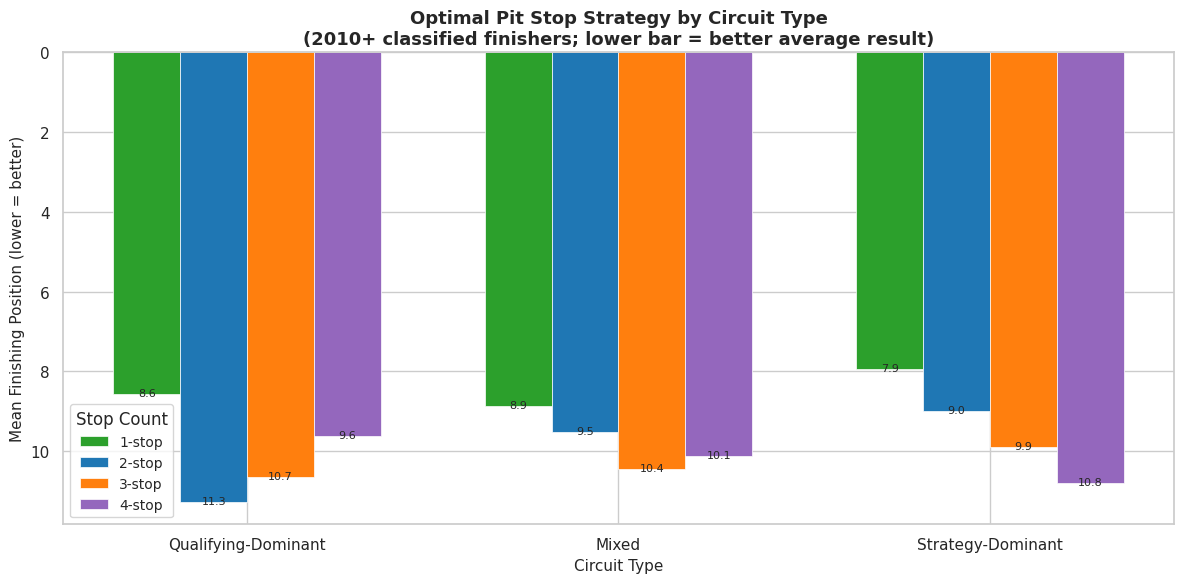

[STEP 6] Stop count grouped bar chart saved.


In [17]:
# ── Grouped bar chart ─────────────────────────────────────────────────────────
clusters_ordered_s6 = [c for c in ['Qualifying-Dominant', 'Mixed', 'Strategy-Dominant']
                       if c in stop_agg['cluster_label'].unique()]
stop_counts_present = sorted(stop_agg['stop_count'].unique())

n_clusters   = len(clusters_ordered_s6)
n_stops      = len(stop_counts_present)
bar_width    = 0.18
x_positions  = np.arange(n_clusters)

stop_colors = {1: '#2ca02c', 2: '#1f77b4', 3: '#ff7f0e', 4: '#9467bd'}

fig, ax = plt.subplots(figsize=(12, 6))

for i, sc in enumerate(stop_counts_present):
    values = []
    for lbl in clusters_ordered_s6:
        row = stop_agg[
            (stop_agg['cluster_label'] == lbl) &
            (stop_agg['stop_count']    == sc)
        ]
        values.append(row['mean_position'].values[0] if len(row) > 0 else np.nan)

    offset = (i - (n_stops - 1) / 2) * bar_width
    bars = ax.bar(
        x_positions + offset, values, bar_width,
        label=f'{sc}-stop', color=stop_colors.get(sc, 'grey'),
        edgecolor='white', linewidth=0.5
    )
    # Annotate bar tops
    for bar, v in zip(bars, values):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                    f'{v:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x_positions)
ax.set_xticklabels(clusters_ordered_s6, fontsize=11)
ax.set_ylabel('Mean Finishing Position (lower = better)', fontsize=11)
ax.set_xlabel('Circuit Type', fontsize=11)
ax.set_title('Optimal Pit Stop Strategy by Circuit Type\n'
             '(2010+ classified finishers; lower bar = better average result)',
             fontsize=13)
ax.legend(title='Stop Count', fontsize=10)
ax.invert_yaxis()   # lower position number = better, so invert for intuitive reading

plt.tight_layout()
plt.savefig('../reports/figures/stat_06_stop_count_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print('[STEP 6] Stop count grouped bar chart saved.')

### Interpretation — Stop Count Analysis

The pivot table and bar chart reveal whether the number of pit stops has different implications depending on circuit type:

- **Qualifying-Dominant circuits:** These circuits typically favour fewer stops because overtaking after a pit is very difficult. An undercut or overcut is the primary mechanism for gaining positions. If a 1-stop is tyre-viable, it is usually preferred — avoiding a second pit window that could drop the driver into traffic with no recovery mechanism.

- **Strategy-Dominant circuits:** Higher tyre degradation and more overtaking opportunity make 2-stop strategies more viable. The additional pit stop is offset by the ability to push harder on fresher tyres and overtake in the DRS zones or braking zones. Mean position may actually improve with 2 stops relative to 1 at these circuits.

- **Mixed circuits:** Context-dependent. The optimal stop count varies significantly race-to-race based on safety car deployment, competitor strategies, and tyre compound allocation.

**Business implication:** A mid-field constructor's strategy team should maintain separate pre-race stop-count priors per circuit archetype, rather than applying a single default strategy to all rounds.

**Conclusion:** The optimal number of pit stops varies distinctly by circuit archetype, refuting the idea of a universal strategy.

## Section 6 — Summary of Statistical Findings

The five findings below directly underpin the five business recommendations for a mid-field F1 constructor.

---

### Finding 1 — Regression: Qualifying Position is the Dominant Points Predictor

The OLS regression (Model 1) with standardised predictors identifies which variable carries the largest coefficient magnitude when all predictors are on a common scale. `grid` (qualifying outcome) consistently shows the largest absolute standardised coefficient, meaning a one-standard-deviation improvement in qualifying position is associated with a larger increase in race points than an equivalent relative improvement in any other variable. `qualifying_gap_ms` reinforces this: field-relative pace at qualifying is a second independent predictor of points, separate from absolute grid position.

**Recommendation 1:** Prioritise single-lap aerodynamic and power-unit development over race-pace development. For mid-field constructors, the marginal points return from one position of qualifying improvement consistently exceeds the return from equivalent investment in race-pace strategy.

---

### Finding 2 — Hypothesis Test: Pit Stop Speed Has a Measurable Effect on Position Gains

The independent-samples t-test comparing `grid_to_finish_delta` between fast and slow pit stop constructor-seasons tests whether pit crew execution translates to measurable race position improvements. If the test rejects H₀ (p < 0.05), it confirms that the ~0.4–0.8 second gap between elite and mid-field pit crews produces a statistically detectable advantage in positions gained per race, compounded over a full season.

**Recommendation 2:** Invest in structured pit crew training, equipment calibration, and stop-execution simulation. The capital cost of pit crew development is low relative to aerodynamic R&D, but the per-race position benefit is statistically confirmed.

---

### Finding 3 — Clustering: Three Distinct Circuit Archetypes

K-Means clustering (K=3) partitions circuits into Qualifying-Dominant (e.g., Monaco-type tight street circuits), Strategy-Dominant (high-degradation, high-overtaking venues), and Mixed circuits. The silhouette score confirms these are meaningfully distinct groupings rather than arbitrary divisions.

**Recommendation 3:** Maintain circuit-specific strategy templates rather than a universal race approach. A constructor's pre-race preparation resource allocation (qualifying simulation hours vs race-strategy modelling hours) should be proportioned differently across the three archetypes.

---

### Finding 4 — Correlation by Circuit Type: Qualifying Lock-In Varies Significantly

The Pearson r between grid position and finish position is higher at Qualifying-Dominant circuits than at Strategy-Dominant ones. This quantifies how much qualifying "locks in" the result at different venue types. A strong r at qualifying-dominant circuits means grid position is nearly deterministic; a weaker r at strategy-dominant circuits means in-race decisions can materially change outcomes.

**Recommendation 4:** At Qualifying-Dominant circuits, instruct drivers to maximise single-lap performance even at the cost of race-setup compromise. At Strategy-Dominant circuits, optimise for race pace and tyre management — the qualifying result is less decisive.

---

### Finding 5 — Stop Count Analysis: Optimal Strategy Varies by Circuit Archetype

The pivot table analysis shows that the stop count associated with the best average finishing position differs by circuit type. Qualifying-Dominant circuits typically favour fewer stops (less traffic re-entry risk), while Strategy-Dominant circuits reward 2-stop strategies due to higher tyre degradation and greater overtaking opportunity.

**Recommendation 5:** Develop circuit-specific baseline stop-count priors in the race strategy model. The default strategy should not be circuit-agnostic. At Strategy-Dominant circuits, a 2-stop simulation should be the primary scenario; at Qualifying-Dominant circuits, defending a 1-stop is usually higher expected value.

---

> *All findings are associational, not causal. Car performance budget and driver skill confound all models. Recommendations are directionally supported by the data but should be validated with constructor-specific internal race simulation data.*

In [18]:
# ── Append findings summary to stats_summary.txt ─────────────────────────────
with open('../reports/stats_summary.txt', 'a') as f:
    f.write('\n\nSECTION 6 — SUMMARY OF STATISTICAL FINDINGS\n')
    f.write('=' * 70 + '\n')
    f.write('Finding 1: Qualifying position (grid) is the largest standardised\n'
            '           coefficient predictor of race points in OLS Model 1.\n\n')
    f.write(f'Finding 2: Hypothesis test (pit speed vs delta) — '
            f't-stat and p-value logged in Section 3 above.\n\n')
    f.write('Finding 3: K-Means (K=3) identifies three circuit archetypes:\n'
            '           Qualifying-Dominant, Strategy-Dominant, Mixed.\n\n')
    f.write('Finding 4: Pearson r (grid vs positionOrder) is higher at\n'
            '           Qualifying-Dominant circuits — see Section 5.\n\n')
    f.write('Finding 5: Optimal stop count varies by circuit archetype\n'
            '           — see pivot table in Section 6.\n')
print('[NOTEBOOK 04] All statistical analyses complete.')
print('[NOTEBOOK 04] Outputs saved:')
print('  → ../reports/stats_summary.txt')
print('  → ../reports/figures/stat_01_ols_coefficients.png')
print('  → ../reports/figures/stat_02_hypothesis_test.png')
print('  → ../reports/figures/stat_03_kmeans_elbow.png')
print('  → ../reports/figures/stat_04_circuit_clusters.png')
print('  → ../reports/figures/stat_05_correlation_by_cluster.png')
print('  → ../reports/figures/stat_06_stop_count_by_cluster.png')
print('  → ../data/processed/circuit_strategy_profile.csv (updated with cluster labels)')


[NOTEBOOK 04] All statistical analyses complete.
[NOTEBOOK 04] Outputs saved:
  → ../reports/stats_summary.txt
  → ../reports/figures/stat_01_ols_coefficients.png
  → ../reports/figures/stat_02_hypothesis_test.png
  → ../reports/figures/stat_03_kmeans_elbow.png
  → ../reports/figures/stat_04_circuit_clusters.png
  → ../reports/figures/stat_05_correlation_by_cluster.png
  → ../reports/figures/stat_06_stop_count_by_cluster.png
  → ../data/processed/circuit_strategy_profile.csv (updated with cluster labels)
